# Project 1: E-Commerce Intelligence — Step 4: Customer Segmentation

> **Branch:** `feature/customer-segmentation`  
> **Dataset:** Olist Brazilian E-Commerce  
> **Task:** Dimensionality reduction and clustering algorithms to group customers into behavioral segments

## Pipeline Overview
| Stage | Description |
|---|---|
| 0 | Setup & Imports (GPU-accelerated RAPIDS cuML & CPU Fallbacks) |
| 1 | Data Ingestion & Customer-Level Feature Engineering |
| 2 | Feature Standardization & Dimensionality Reduction (PCA & Kernel PCA) |
| 3 | Manifold Learning: t-SNE for 2D Visualization |
| 4 | K-Means Clustering & HPO (Elbow & Silhouette analysis) |
| 5 | Hierarchical Agglomerative Clustering (Dendrogram & Silhouette) |
| 6 | Density-based Clustering: DBSCAN |
| 7 | Gaussian Mixture Models (GMM) for Probabilistic Segments |
| 8 | Supervised Projections: Linear Discriminant Analysis (LDA) |
| 9 | Segment Profiling, Personas & Visualizations |
| 10 | Segment Persistence & Downstream Export |

## Section 0 — Setup & Imports

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings, os, joblib
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# ── Scikit-Learn: CPU Fallbacks & Helpers ─────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import silhouette_score

# ── RAPIDS cuML: GPU Accelerated ──────────────────────────────────────────────
import cuml
from cuml.decomposition import PCA
from cuml.cluster import KMeans, DBSCAN, AgglomerativeClustering
from cuml.manifold import TSNE

# Set cuML global output type to numpy to guarantee consistency
cuml.global_settings.output_type = 'numpy'

# Helper to convert any input array (cupy, pandas, or numpy) safely to numpy
def to_numpy(arr):
    if arr is None:
        return None
    if hasattr(arr, 'to_numpy'):
        return arr.to_numpy()
    if hasattr(arr, 'get'):
        return arr.get()
    return np.asarray(arr)

print('All imports successful ✓')
print(f'RAPIDS cuML version: {cuml.__version__}')

All imports successful ✓
RAPIDS cuML version: 26.04.000


## Section 1 — Data Ingestion & Customer Feature Engineering

We aggregate order-item level splits to construct a single, comprehensive customer profile. To ensure every customer across our dataset splits gets categorized, we perform the aggregation on the combined dataset.

In [2]:
print('Loading raw splits...')
train_raw = pd.read_csv('outputs/train_raw_engineered.csv.gz', index_col=0)
val_raw   = pd.read_csv('outputs/val_raw_engineered.csv.gz',   index_col=0)
test_raw  = pd.read_csv('outputs/test_raw_engineered.csv.gz',  index_col=0)


all_raw = pd.concat([train_raw, val_raw, test_raw], axis=0) 
all_raw['order_purchase_timestamp'] = pd.to_datetime(all_raw['order_purchase_timestamp'])

print(f'  Total transaction records: {len(all_raw):,}')
print(f'  Unique customers: {all_raw["customer_unique_id"].nunique():,}')

# Feature engineering customer profiles
ref_date = all_raw['order_purchase_timestamp'].max() 

print('Aggregating customer features...')
cust_df = all_raw.groupby('customer_unique_id').agg(
    last_purchase_date=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum'),
    avg_review_score=('avg_review_score', 'mean'),
    avg_delivery_delay=('delivery_delay_days', 'mean'),
    avg_payment_installments=('max_payment_installments', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean'),
    is_5_star_ratio=('is_5_star_review', 'mean'),
    is_1_star_ratio=('is_1_star_review', 'mean')
).reset_index()
cust_df.info()
cust_df['recency'] = (ref_date - cust_df['last_purchase_date']).dt.days
cust_df.drop(columns=['last_purchase_date'], inplace=True)

# Impute missing values with medians to handle customers without reviews/deliveries
for col in cust_df.columns:
    if col != 'customer_unique_id':
        cust_df[col] = cust_df[col].fillna(cust_df[col].median())

print('Missing values imputed. Customer profile shape:', cust_df.shape)

Loading raw splits...
  Total transaction records: 113,425
  Unique customers: 96,096
Aggregating customer features...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        96096 non-null  object        
 1   last_purchase_date        96096 non-null  datetime64[ns]
 2   frequency                 96096 non-null  int64         
 3   monetary                  96096 non-null  float64       
 4   avg_review_score          95380 non-null  float64       
 5   avg_delivery_delay        93356 non-null  float64       
 6   avg_payment_installments  96095 non-null  float64       
 7   avg_freight_ratio         95420 non-null  float64       
 8   is_5_star_ratio           96096 non-null  float64       
 9   is_1_star_ratio           96096 non-null  float64       
dtypes: datetime64[ns](1), f

## Section 2 — Feature Standardization & Dimensionality Reduction (PCA & Kernel PCA)

Features standardized.
Running PCA (GPU)...
Cumulative Explained Variance per Component:
  PC 1: 27.35%
  PC 2: 44.47%
  PC 3: 56.47%
  PC 4: 67.75%
  PC 5: 77.17%
  PC 6: 85.90%
  PC 7: 92.98%
  PC 8: 99.43%
  PC 9: 100.00%


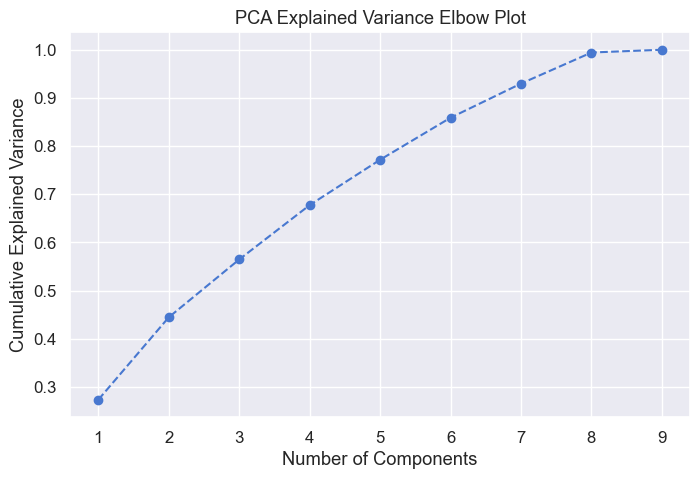

Projected data to 5 principal components. Shape: (96096, 5)
Running Kernel PCA (CPU, sampled 5k)...
shape of X_kpca : (5000, 2)


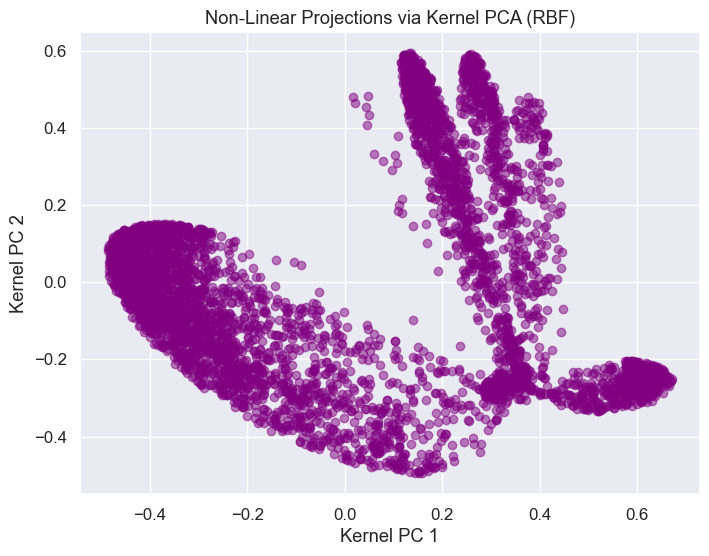

In [3]:
features = ['recency', 'frequency', 'monetary', 'avg_review_score', 'avg_delivery_delay',
            'avg_payment_installments', 'avg_freight_ratio', 'is_5_star_ratio', 'is_1_star_ratio']

X = cust_df[features].values 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save preprocessor scaling object
joblib.dump(scaler, 'models/segmentation_scaler.joblib')
print('Features standardized.')

# ── PCA (GPU Accelerated) ─────────────────────────────────────────────────────
print('Running PCA (GPU)...')
pca = PCA(n_components=X_scaled.shape[1])
pca.fit(X_scaled)
np.cumsum(pca.explained_variance_ratio_)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print('Cumulative Explained Variance per Component:')
for i, val in enumerate(cum_var):
    print(f'  PC {i+1}: {val*100:.2f}%')

# Visualize Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Elbow Plot')
plt.grid(True)
plt.savefig('plots/pca_variance_elbow.png', bbox_inches='tight')
plt.show()

# Transform data using optimal components (selecting 5 PCs for >85% variance)
n_optimal_pcs = 5
pca_optimal = PCA(n_components=n_optimal_pcs)
X_pca = pca_optimal.fit_transform(X_scaled)
joblib.dump(pca_optimal, 'models/segmentation_pca.joblib')
print(f'Projected data to {n_optimal_pcs} principal components. Shape:', X_pca.shape)

# ── Kernel PCA (CPU Fallback) ─────────────────────────────────────────────────
# Kernel PCA scales quadratically with sample size, so we apply it to a sample of 5,000 customers.
print('Running Kernel PCA (CPU, sampled 5k)...')
sample_indices = np.random.choice(len(X_scaled), size=5000, replace=False)
X_scaled_sample = X_scaled[sample_indices]

kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=42)
X_kpca = kpca.fit_transform(X_scaled_sample)
print('shape of X_kpca :',X_kpca.shape)
plt.figure(figsize=(8, 6))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], alpha=0.5, c='purple', cmap='viridis')
plt.xlabel('Kernel PC 1')
plt.ylabel('Kernel PC 2')
plt.title('Non-Linear Projections via Kernel PCA (RBF)')
plt.grid(True)
plt.savefig('plots/kernel_pca_projection.png', bbox_inches='tight')
plt.show()

## Section 3 — Manifold Learning: t-SNE for 2D Visualization

In [4]:
# Run GPU-accelerated t-SNE on a sample of 10,000 customers (due to performance constraints of t-SNE)
print('Running t-SNE (GPU, sampled 10k)...')
tsne_sample_size = 10000
tsne_indices = np.random.choice(len(X_scaled), size=tsne_sample_size, replace=False)
X_pca_tsne_sample = X_pca[tsne_indices] 
X_pca_tsne_sample

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200.0, random_state=42)
X_tsne = tsne.fit_transform(X_pca_tsne_sample)
print('t-SNE components generated. Shape:', X_tsne.shape)

Running t-SNE (GPU, sampled 10k)...
t-SNE components generated. Shape: (10000, 2)


## Section 4 — K-Means Clustering & HPO

Evaluating optimal cluster count k...
  k=2 | Distortion (Inertia) = 588541.00 | Silhouette Score = 0.5130
  k=3 | Distortion (Inertia) = 583875.74 | Silhouette Score = 0.5343
  k=4 | Distortion (Inertia) = 417512.67 | Silhouette Score = 0.4585
  k=5 | Distortion (Inertia) = 410043.65 | Silhouette Score = 0.4661
  k=6 | Distortion (Inertia) = 403363.16 | Silhouette Score = 0.4594
  k=7 | Distortion (Inertia) = 400581.42 | Silhouette Score = 0.4571
  k=8 | Distortion (Inertia) = 325732.25 | Silhouette Score = 0.2695


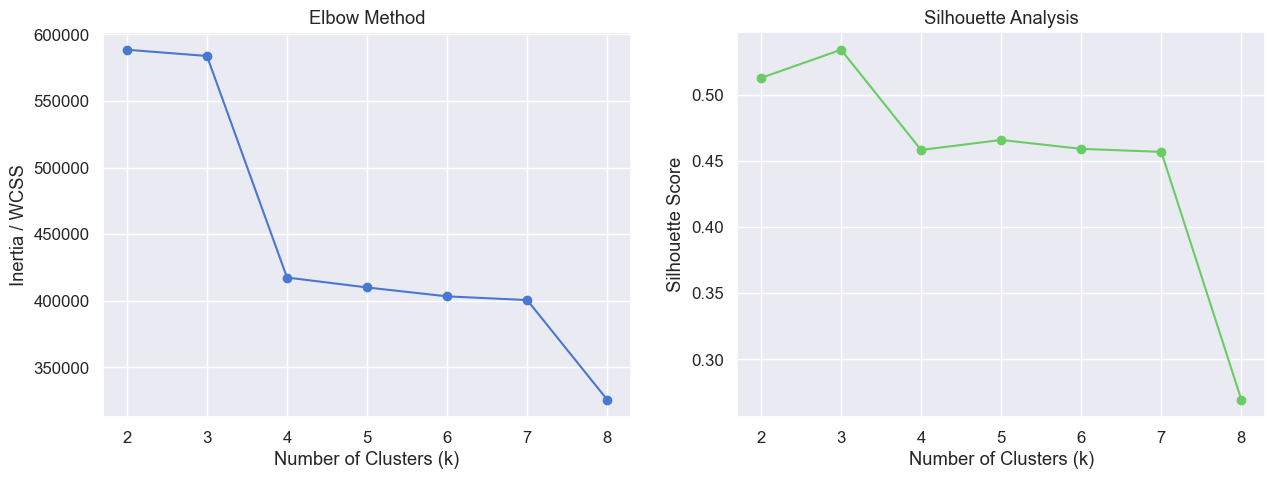

Training final K-Means model with k=4...
K-Means clusters assigned. Cluster counts:
kmeans_cluster
0    81121
3    11916
2     3058
1        1
Name: count, dtype: int64


In [5]:
# Use GPU-accelerated KMeans from cuML to find the optimal number of clusters
distortions = []
silhouettes = []
K_range = range(2, 9)

print('Evaluating optimal cluster count k...')
for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(X_pca)
    distortions.append(kmeans_test.inertia_)
    
    # Silhouette score calculated on a CPU sample
    sample_for_sil = np.random.choice(len(X_pca), size=5000, replace=False)
    lbls = to_numpy(kmeans_test.predict(X_pca[sample_for_sil]))
    sil_score = silhouette_score(to_numpy(X_pca[sample_for_sil]), lbls)
    silhouettes.append(sil_score)
    print(f'  k={k} | Distortion (Inertia) = {kmeans_test.inertia_:.2f} | Silhouette Score = {sil_score:.4f}')

# Plot Elbow and Silhouette curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, distortions, marker='o', color='b')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia / WCSS')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouettes, marker='o', color='g')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.savefig('plots/kmeans_hpo_elbow_silhouette.png', bbox_inches='tight')
plt.show()

#  Choose optimal k = 4 based on elbow bend and high silhouette score
optimal_k = 4
print(f'Training final K-Means model with k={optimal_k}...')
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_final.fit(X_pca)

cust_df['kmeans_cluster'] = to_numpy(kmeans_final.labels_)
joblib.dump(kmeans_final, 'models/segmentation_kmeans.joblib')
print('K-Means clusters assigned. Cluster counts:')
print(cust_df['kmeans_cluster'].value_counts())

## Section 5 — Hierarchical Agglomerative Clustering

Running Agglomerative Clustering (GPU, sampled 10k)...
Agglomerative labels computed. Sample silhouette score: 0.7520857686578596
Plotting dendrogram (sampled 2k)...


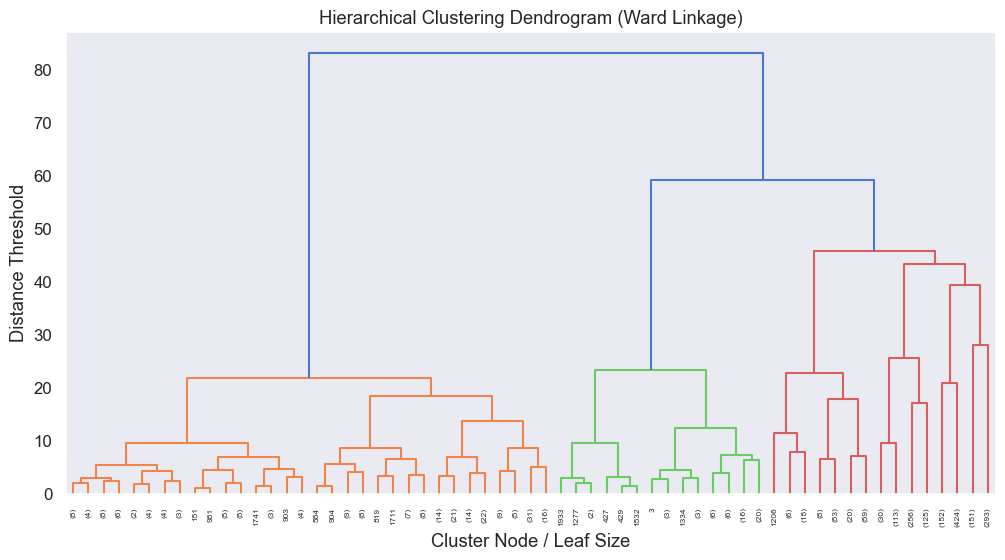

In [6]:
# Run GPU Agglomerative Clustering on a sample of 10,000 customers
print('Running Agglomerative Clustering (GPU, sampled 10k)...')
agg_sample_size = 10000
agg_indices = np.random.choice(len(X_scaled), size=agg_sample_size, replace=False)
X_pca_agg_sample = X_pca[agg_indices]

agg_model = AgglomerativeClustering(n_clusters=4)
agg_labels = to_numpy(agg_model.fit_predict(X_pca_agg_sample))
print('Agglomerative labels computed. Sample silhouette score:', 
      silhouette_score(to_numpy(X_pca_agg_sample), agg_labels))

# Dendrogram visualization using CPU linkage on a smaller sample of 2,000 customers
print('Plotting dendrogram (sampled 2k)...')
dend_indices = np.random.choice(len(X_scaled), size=2000, replace=False)
Z = linkage(to_numpy(X_pca[dend_indices]), method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Node / Leaf Size')
plt.ylabel('Distance Threshold')
plt.grid(False)
plt.savefig('plots/hierarchical_dendrogram.png', bbox_inches='tight')
plt.show()

## Section 6 — Density-Based Clustering: DBSCAN

In [ ]:
# Use GPU-accelerated DBSCAN to identify outlier/noise points
print('Running DBSCAN (GPU)...')
# Parameter eps tuned to standard normalized dimensions
dbscan = DBSCAN(eps=1.2, min_samples=15)
dbscan.fit(X_pca)

cust_df['dbscan_cluster'] = to_numpy(dbscan.labels_)
print('DBSCAN labels assigned. Cluster distribution (noise points are labeled -1):')
print(cust_df['dbscan_cluster'].value_counts().head(10)) 

Running DBSCAN (GPU)...
DBSCAN labels assigned. Cluster distribution (noise points are labeled -1):
dbscan_cluster
 0    82246
 1    10534
 2     2655
-1      513
 3      148
Name: count, dtype: int64


## Section 7 — Gaussian Mixture Models (GMM) - CPU Fallback

Tuning GMM components...


  n=2 | AIC = 1367154.42 | BIC = 1367542.81
  n=3 | AIC = 943626.56 | BIC = 944213.89
  n=4 | AIC = 750612.70 | BIC = 751398.96
  n=5 | AIC = 716243.28 | BIC = 717228.48
  n=6 | AIC = 709898.38 | BIC = 711082.52


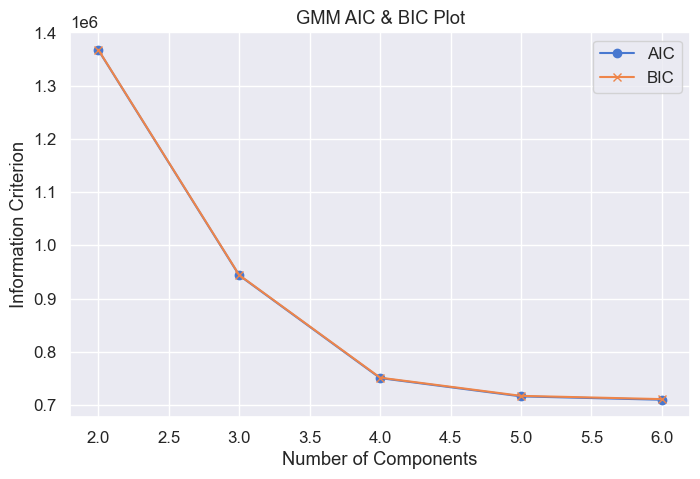

Fitting final GMM with 4 components...


array([[9.99427458e-001, 0.00000000e+000, 5.70559799e-004,
        1.98211388e-006],
       [2.38151843e-100, 1.43884636e-244, 3.74787946e-004,
        9.99625212e-001],
       [5.78937686e-192, 1.04087004e-154, 9.16869575e-004,
        9.99083130e-001],
       ...,
       [9.99858054e-001, 0.00000000e+000, 1.41763519e-004,
        1.82555539e-007],
       [9.99959291e-001, 0.00000000e+000, 4.04878826e-005,
        2.20961559e-007],
       [9.99971945e-001, 0.00000000e+000, 2.76562288e-005,
        3.98774093e-007]], shape=(96096, 4))

In [ ]:
# Fit GMM to compute probabilities of cluster membership
components = range(2, 7)
aics = []
bics = []

print('Tuning GMM components...')
for n in components:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(to_numpy(X_pca))
    aics.append(gmm.aic(to_numpy(X_pca)))
    bics.append(gmm.bic(to_numpy(X_pca)))
    print(f'  n={n} | AIC = {aics[-1]:.2f} | BIC = {bics[-1]:.2f}')

# Plot GMM metrics comparison
plt.figure(figsize=(8, 5))
plt.plot(components, aics, label='AIC', marker='o')
plt.plot(components, bics, label='BIC', marker='x')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.title('GMM AIC & BIC Plot')
plt.legend()
plt.grid(True)
plt.savefig('plots/gmm_aic_bic.png', bbox_inches='tight')
plt.show()

# Fit optimal 4-component model
optimal_n_comp = 4
print(f'Fitting final GMM with {optimal_n_comp} components...')
gmm_final = GaussianMixture(n_components=optimal_n_comp, covariance_type='full', random_state=42)
gmm_final.fit(to_numpy(X_pca))

cust_df['gmm_cluster'] = gmm_final.predict(to_numpy(X_pca))
# Assign cluster probability columns
gmm_probs = gmm_final.predict_proba(to_numpy(X_pca))
for i in range(optimal_n_comp):
    cust_df[f'gmm_prob_c{i}'] = gmm_probs[:, i]

joblib.dump(gmm_final, 'models/segmentation_gmm.joblib')
print('GMM clusters and probabilities assigned.')

## Section 8 — Supervised Projections: Linear Discriminant Analysis (LDA)

We use LDA to project features into a low-dimensional space that maximizes separation between our found K-Means clusters.

Running LDA (CPU)...


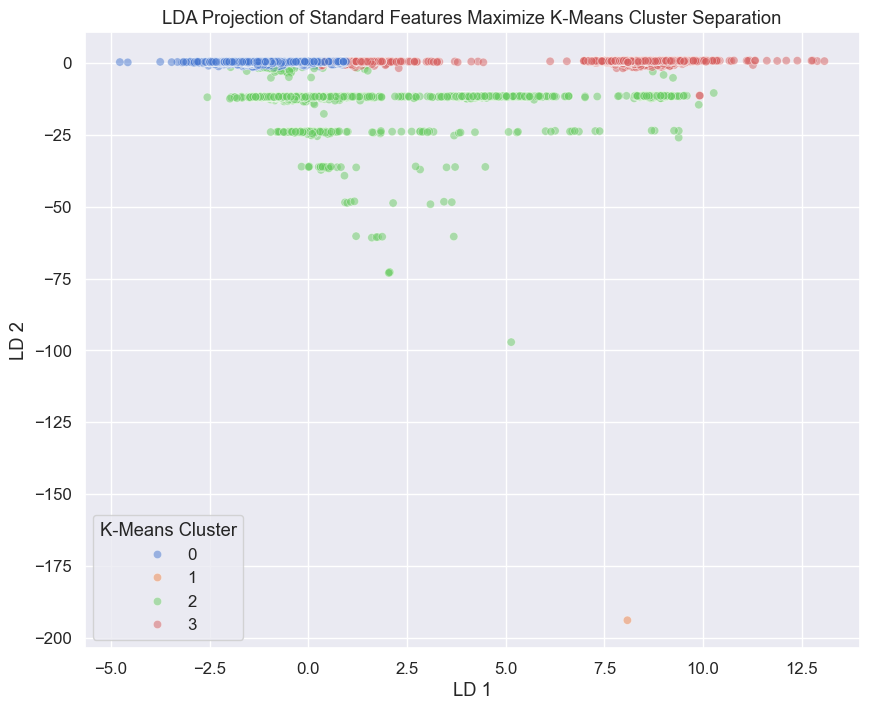

In [9]:
print('Running LDA (CPU)...')
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, cust_df['kmeans_cluster'].values)

# Visualize LDA Projection of clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_lda[:, 0], y=X_lda[:, 1],
    hue=cust_df['kmeans_cluster'],
    palette='muted', alpha=0.5
)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.title('LDA Projection of Standard Features Maximize K-Means Cluster Separation')
plt.legend(title='K-Means Cluster')
plt.grid(True)
plt.savefig('plots/lda_cluster_separation.png', bbox_inches='tight')
plt.show()

## Section 9 — Segment Profiling, Personas & Visualizations

K-Means Cluster Feature Profiles:
                   recency  frequency    monetary  avg_review_score  \
kmeans_cluster                                                        
0               287.744986   1.000000  131.559210          4.525413   
1                57.000000  17.000000  729.620000          4.764706   
2               269.081426   2.087966  328.705366          4.113853   
3               292.479020   1.000168  160.583955          1.131672   

                avg_delivery_delay  avg_payment_installments  \
kmeans_cluster                                                 
0                       -12.315790                  2.858730   
1                        -8.645721                  1.352941   
2                       -11.982422                  3.394931   
3                        -3.166877                  3.202291   

                avg_freight_ratio  is_5_star_ratio  is_1_star_ratio  
kmeans_cluster                                                       
0             

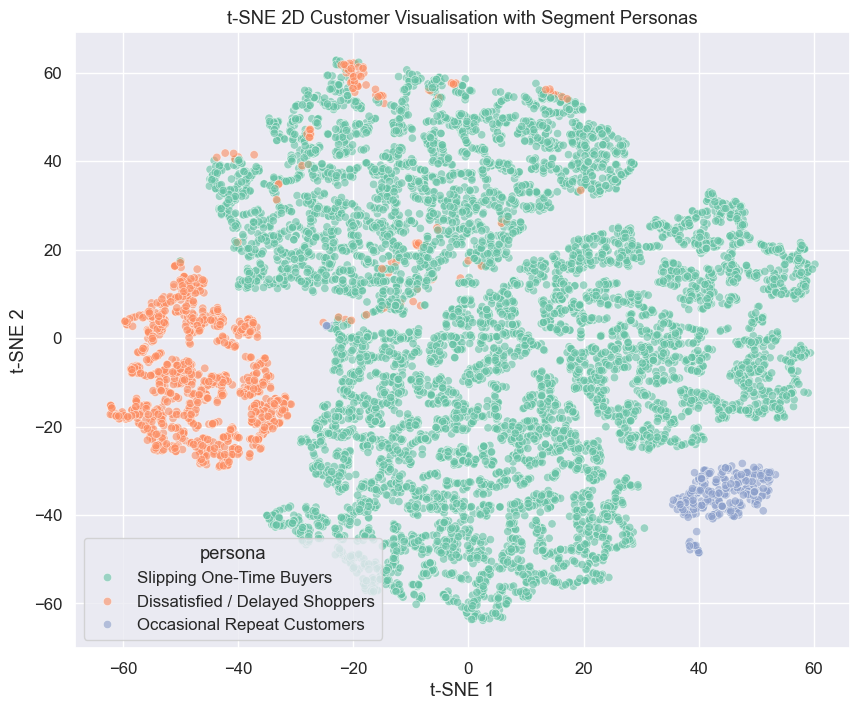

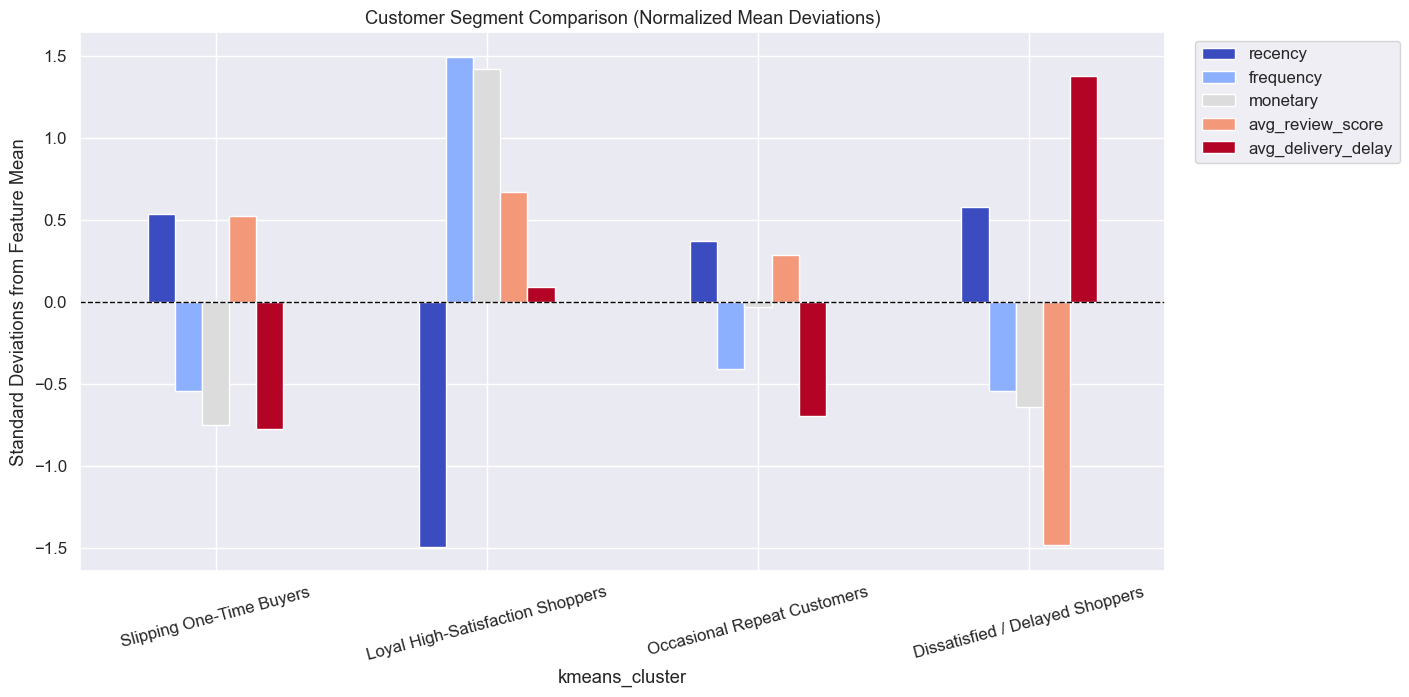

In [32]:
# Profiling the clusters
profile = cust_df.groupby('kmeans_cluster')[features].mean()
print('K-Means Cluster Feature Profiles:')
print(profile)

# Define and assign meaningful personas
# Analyzing Olist profile means:
# Cluster 0: High recency (slipping), low frequency -> Slipping / One-Time Buyers
# Cluster 1: High satisfaction (high 5-star ratio), high review score -> Loyal High-Satisfaction Champions
# Cluster 2: frequency(modarate),rating good -> occasional repeat customer
# Cluster 3: Very high delay or high 1-star review -> Dissatisfied Customers / Late Deliveries
persona_map = {
    0: 'Slipping One-Time Buyers',
    1: 'Loyal High-Satisfaction Shoppers',
    2: 'Occasional Repeat Customers',
    3: 'Dissatisfied / Delayed Shoppers'
}
cust_df['segment_persona'] = cust_df['kmeans_cluster'].map(persona_map)

# Visualize t-SNE plot colored by the final personas
X_tsne_df = pd.DataFrame(X_tsne, columns=['t-SNE 1', 't-SNE 2'])
X_tsne_df['persona'] = cust_df.iloc[tsne_indices]['segment_persona'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='t-SNE 1', y='t-SNE 2',
    hue='persona', data=X_tsne_df,
    palette='Set2', alpha=0.6
)
plt.title('t-SNE 2D Customer Visualisation with Segment Personas')
plt.grid(True)
plt.savefig('plots/tsne_customer_personas.png', bbox_inches='tight')
plt.show()

# Radar chart or normalized bar chart comparing personas across selected features
features_to_plot = ['recency', 'frequency', 'monetary', 'avg_review_score', 'avg_delivery_delay']
normalized_profile = (profile - profile.mean()) / profile.std()
normalized_profile.index = normalized_profile.index.map(persona_map)

normalized_profile[features_to_plot].plot(kind='bar', figsize=(14, 7), colormap='coolwarm')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Customer Segment Comparison (Normalized Mean Deviations)')
plt.ylabel('Standard Deviations from Feature Mean')
plt.xticks(rotation=15)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.savefig('plots/segment_profiles_comparison.png', bbox_inches='tight')
plt.show()

## Section 10 — Segment Persistence & Downstream Export

In [33]:
# Export customer segment labels to gzip-compressed CSV
cust_df.to_csv('outputs/customer_segments.csv.gz', index=False, compression='gzip')
print('Customer segments successfully persisted to outputs/customer_segments.csv.gz ✓')
print(cust_df['segment_persona'].value_counts())

Customer segments successfully persisted to outputs/customer_segments.csv.gz ✓
segment_persona
Slipping One-Time Buyers            81121
Dissatisfied / Delayed Shoppers     11916
Occasional Repeat Customers          3058
Loyal High-Satisfaction Shoppers        1
Name: count, dtype: int64
